In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import glob
seed = 0
np.random.seed(seed)


We want to automate a process to 'fake' charge jumps. 
This can be achieved by just copy pasting the whole plot at the place of the jump.
We want to randomize when to jump and where to jump.
We also want to be able to shift the template to where the last scan finished.
For simplicity, we can assume all "jumps" rewind the qubit to the original state. 
That is not what I have used bellow for various reasons, but we can assume that when making template shifts.


In [3]:
# file paths - Change to paths on your machine
basedir='/home/export/jgaytanv/quantum/NEXUS_Qubits/'
tomography_datapath = basedir+'Data/Tomography/'
template_datapath = basedir+'SimulatedData_Gen/Templates/'
PtbyPtoutput_datapath = basedir+'Data/PtbyPt_output/'

In [ ]:
# Load templates and template sigmas (errors) for each qubit
os.chdir(str(template_datapath))

# Template data
Q1_templ = np.random.normal(0, 1, size=200)

# Error data
Q1_sigma = np.load('Q1_SC_sigma_full.npy', allow_pickle=True)

# Check data:

print("Data type:", type(Q1_templ))
print("Shape:", Q1_templ.shape)
print("Data:", Q1_templ)
print("Error:", Q1_sigma)

FileNotFoundError: [Errno 2] No such file or directory: 'Q1_SC_sigma_full.npy'

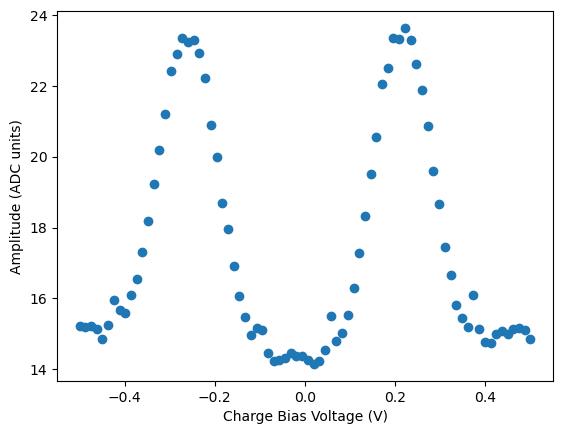

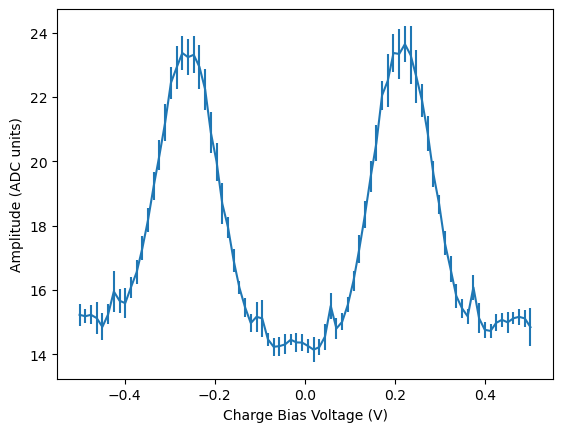

In [ ]:
# Print template
# Load vsweep
os.chdir(basedir+'Data')
vsweep = np.load('vsweep.npy', allow_pickle=True)

# Plot Template with and without error - These are in ADC values
plt.scatter(vsweep, Q1_templ)
plt.xlabel("Charge Bias Voltage (V)")
plt.ylabel("Amplitude (ADC units)")
plt.show()
plt.errorbar(vsweep, Q1_templ, yerr= Q1_sigma)
plt.xlabel("Charge Bias Voltage (V)")
plt.ylabel("Amplitude (ADC units)")
plt.show()

In [8]:
# Write to txt
with open("Q1_SC_templ.txt", "w") as f:
    f.write(str(Q1_templ))
    
with open("Q1_SC_sigma.txt", "w") as f:
    f.write(str(Q1_sigma))

NameError: name 'Q1_sigma' is not defined

In [ ]:
# State Variables
# Frequency of jumps
f = 0.05

# Number of scans
n_scans = 100

# Which scan to jump
do_jump = np.random.choice([0, 1], size=n_scans, p=[1-f, f])
print(do_jump)

# Count number of jumps so far
n_jumps = np.count_nonzero(do_jump)
print(n_jumps)

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
5


In [ ]:
# Voltage index of jump: assuming maximum 1 jump per scan
n_inputs = 80
i_jump = np.random.randint(low=0, high=n_inputs-1) #generate 1 for test purposes
print(i_jump)

vi_list = np.zeros_like(do_jump)
print(vi_list)
vi_list[do_jump == 1] = np.random.randint(0, n_inputs+1, size=np.sum(do_jump == 1))
print(vi_list[do_jump==1])

# Count amount of displacement so far

cum_jumps = np.count_nonzero(vi_list) % 80
print(cum_jumps)


NameError: name 'np' is not defined

In [ ]:
# If has jump
# Make new ndarr with jump
rep = 0
Q1_longtempl = np.tile(Q1_templ, 2)  # repeat template 2 times
if i_jump <= 30: #make sure the "jump" is different than the original
    rep = 35
# Part before jump
part1 = Q1_longtempl[:i_jump]

# Jump once
part2 = Q1_longtempl[rep:rep+n_inputs-i_jump]  

# Combine them
Q1_jump = np.concatenate([part1, part2])

print(Q1_jump)

[15.22810142 15.1837104  14.25367486 14.30768691 14.45381063 14.37051693
 14.36400523 14.26122469 14.14435302 14.22353951 14.55089071 15.50597528
 14.80293838 15.00882007 15.53934336 16.29392892 17.27073109 18.33619204
 19.52055619 20.57023946 22.05491081 22.50853748 23.37083888 23.34005468
 23.64476876 23.30627275 22.6307028  21.8899834  20.86986274 19.60277702
 18.66877726 17.46089211 16.65317533 15.81419423 15.43378053 15.17854753
 16.08382932 15.11861227 14.76162505 14.72726206 14.97957404 15.07324095
 14.99371137 15.1195269  15.16613806 15.11710052 14.84507473 15.22810142
 15.1837104  15.22863281 15.12636976 14.85421763 15.24081178 15.95299722
 15.66698245 15.59060545 16.08457045 16.55131686 17.30205484 18.18520194
 19.24226798 20.19999277 21.21659051 22.43865213 22.91477715 23.37029001
 23.24028777 23.31369603 22.93764836 22.23860306 20.89412519 19.99420431
 18.68686456 17.95417858 16.91558667 16.07409328 15.45946044 14.97008279
 15.16623866 15.11595045]


Need to make this a function: when do_jump[scan #] = 1
input: template SHIFTED, scan #, i_jump[scan #] 
output: scan W/ JUMP


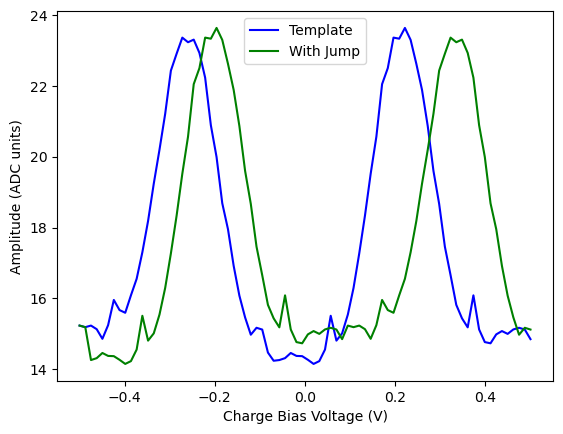

In [ ]:
# Print new data
# Load vsweep
os.chdir(basedir+'Data')
vsweep = np.load('vsweep.npy', allow_pickle=True)

# Plot without error
plt.plot(vsweep, Q1_templ, color='blue', label='Template')
plt.plot(vsweep, Q1_jump, color='green', label='With Jump')
plt.xlabel("Charge Bias Voltage (V)")
plt.ylabel("Amplitude (ADC units)")
plt.legend() 
plt.show()

In [ ]:
#if do_jump==1, call function and apply jump on the n-th scan at the i-jump
def apply_jump(scan, i_jump):
    rep=0
    #repeat template 2 times
    Q1_longtempl = np.tile(scan, 2) 
    #avoid early (or too late!) jumps
    if i_jump <= 20 or i_jump>=70: 
        rep = int(np.random.uniform(25, 65))
    #before jump
    part1 = Q1_longtempl[:i_jump]
    #after jump
    part2 = Q1_longtempl[rep:rep+len(scan)-i_jump] 
    #combine them
    scan = np.concatenate([part1, part2])
    return scan

Total scans available (templ_full only): 5
Using n_scans: 30
vi_list: [56 75 60 24 52]
Number of jumps: 5
Applied jump to scan 0 at voltage index 56
Applied jump to scan 1 at voltage index 75
Applied jump to scan 2 at voltage index 60
Applied jump to scan 3 at voltage index 24
Applied jump to scan 4 at voltage index 52


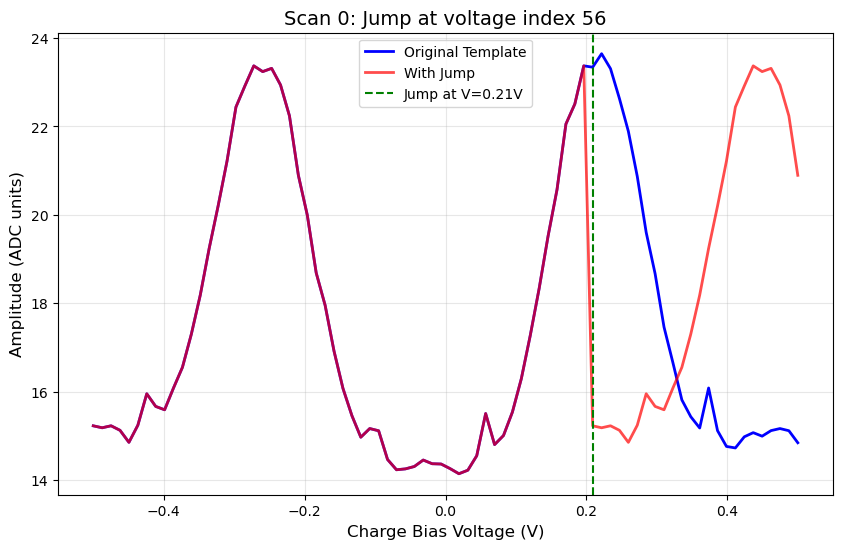

In [ ]:
f = 1
n_inputs = 80
n_scans = 30

# Read ONLY templates with 'templ_full' in the filename
all_files = sorted(glob.glob(os.path.join(template_datapath, '*templ_full*.npy')))
all_scans = [np.load(file, allow_pickle=True) for file in all_files]

print(f"Total scans available (templ_full only): {len(all_scans)}")
print(f"Using n_scans: {n_scans}")

# Check if we have enough scans
if n_scans > len(all_scans):
    print(f"Warning: Requested {n_scans} scans but only {len(all_scans)} available!")
    n_scans = len(all_scans)

# Select n_scans from all available scans
scans = all_scans[:n_scans]

# Save original scans for comparison
import copy
scans_original = copy.deepcopy(scans)

# Randomly apply jumps to scans
do_jump = np.random.choice([0, 1], size=n_scans, p=[1-f, f])

# Create vi_list to randomly assign point where jump will happen
vi_list = np.zeros_like(do_jump)
vi_list[do_jump == 1] = np.random.randint(0, n_inputs+1, size=np.sum(do_jump == 1))

print(f"vi_list: {vi_list}")
print(f"Number of jumps: {np.sum(do_jump)}")

# Check if any jumps exist
if not np.any(vi_list):
    print("No jumps were generated! Increase f or n_scans.")
else:
    # Loop over scans where jump happens and apply jump
    jump_indices = np.nonzero(vi_list)[0]
    
    for i in jump_indices:
        i_jump = vi_list[i]
        scans[i] = apply_jump(scans[i], i_jump)
        print(f"Applied jump to scan {i} at voltage index {i_jump}")
    
    # Plot the first scan that had a jump
    first_jump_idx = jump_indices[0]
    Q1_template = scans_original[first_jump_idx][:n_inputs]
    Q1_jump = scans[first_jump_idx][:n_inputs]
    
    # Load vsweep
    os.chdir(basedir + 'Data')
    vsweep = np.load('vsweep.npy', allow_pickle=True)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(vsweep, Q1_template, color='blue', label='Original Template', linewidth=2)
    plt.plot(vsweep, Q1_jump, color='red', label='With Jump', linewidth=2, alpha=0.7)
    plt.axvline(vsweep[int(vi_list[first_jump_idx])], color='green', linestyle='--', 
                label=f'Jump at V={vsweep[int(vi_list[first_jump_idx])]:.2f}V')
    plt.xlabel("Charge Bias Voltage (V)", fontsize=12)
    plt.ylabel("Amplitude (ADC units)", fontsize=12)
    plt.title(f"Scan {first_jump_idx}: Jump at voltage index {int(vi_list[first_jump_idx])}", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Total template files found: 5
Loaded: Q1_SC_templ_full.npy -> Qubit: Q1, State: SC, Shape: (80,)
Loaded: Q2_SC_templ_full.npy -> Qubit: Q2, State: SC, Shape: (80,)
Loaded: Q3_SC_templ_full.npy -> Qubit: Q3, State: SC, Shape: (80,)
Loaded: Q4_SC_templ_full.npy -> Qubit: Q4, State: SC, Shape: (80,)
Loaded: Q4_SO_templ_full.npy -> Qubit: Q4, State: SO, Shape: (80,)


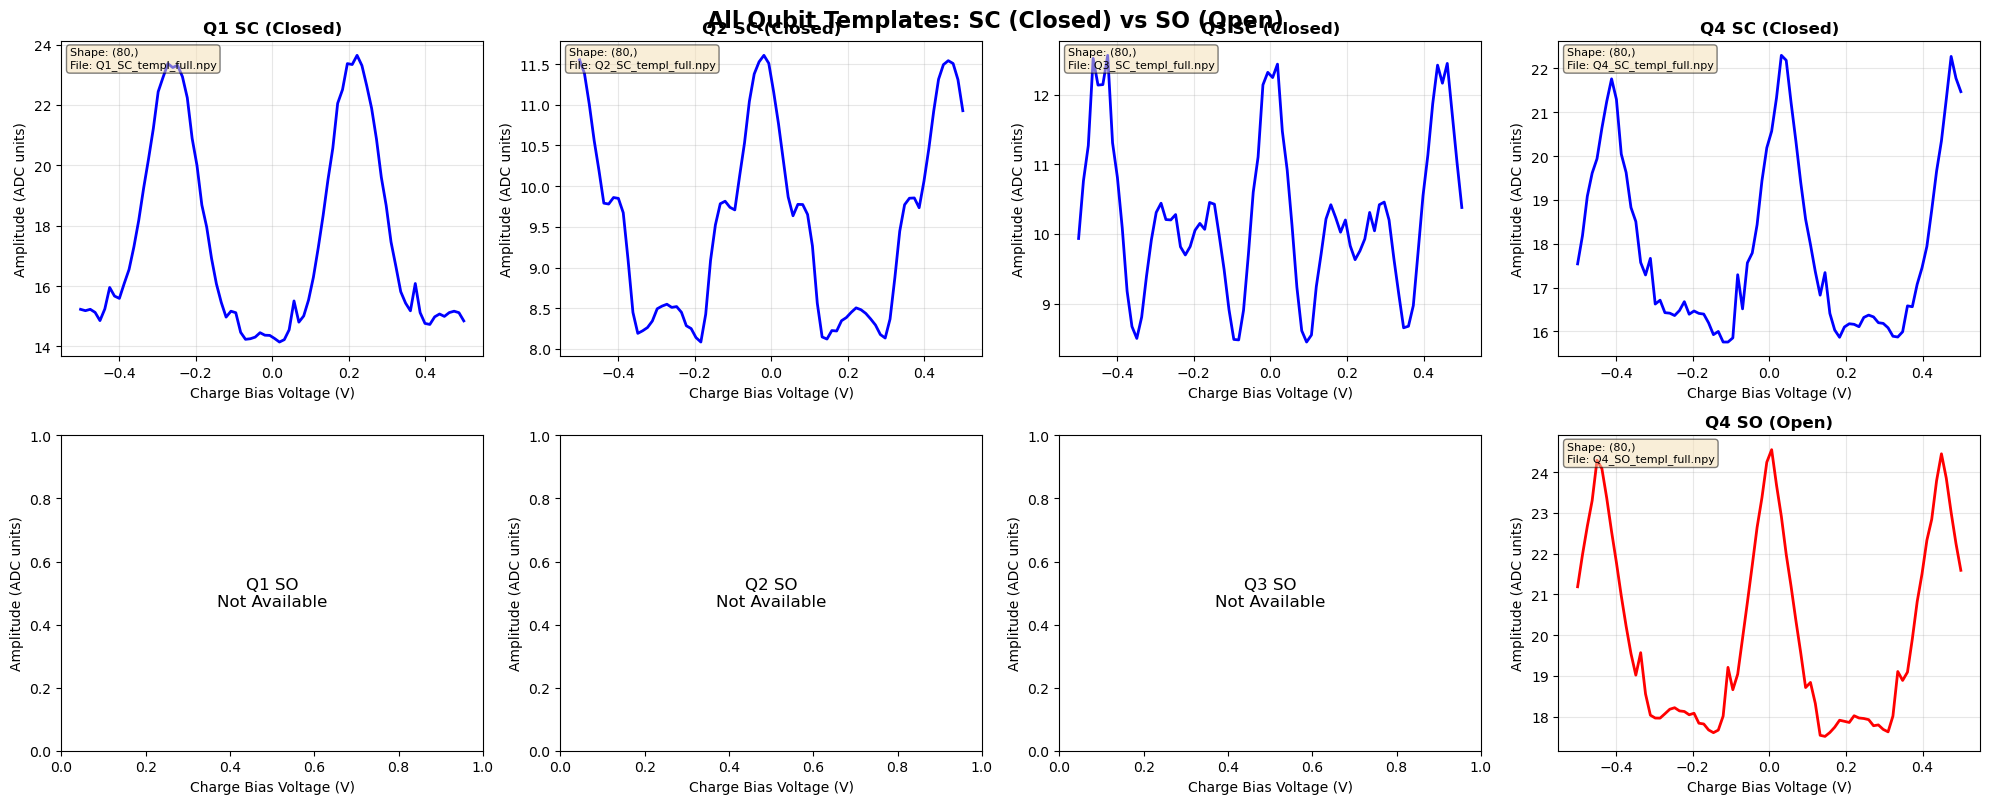

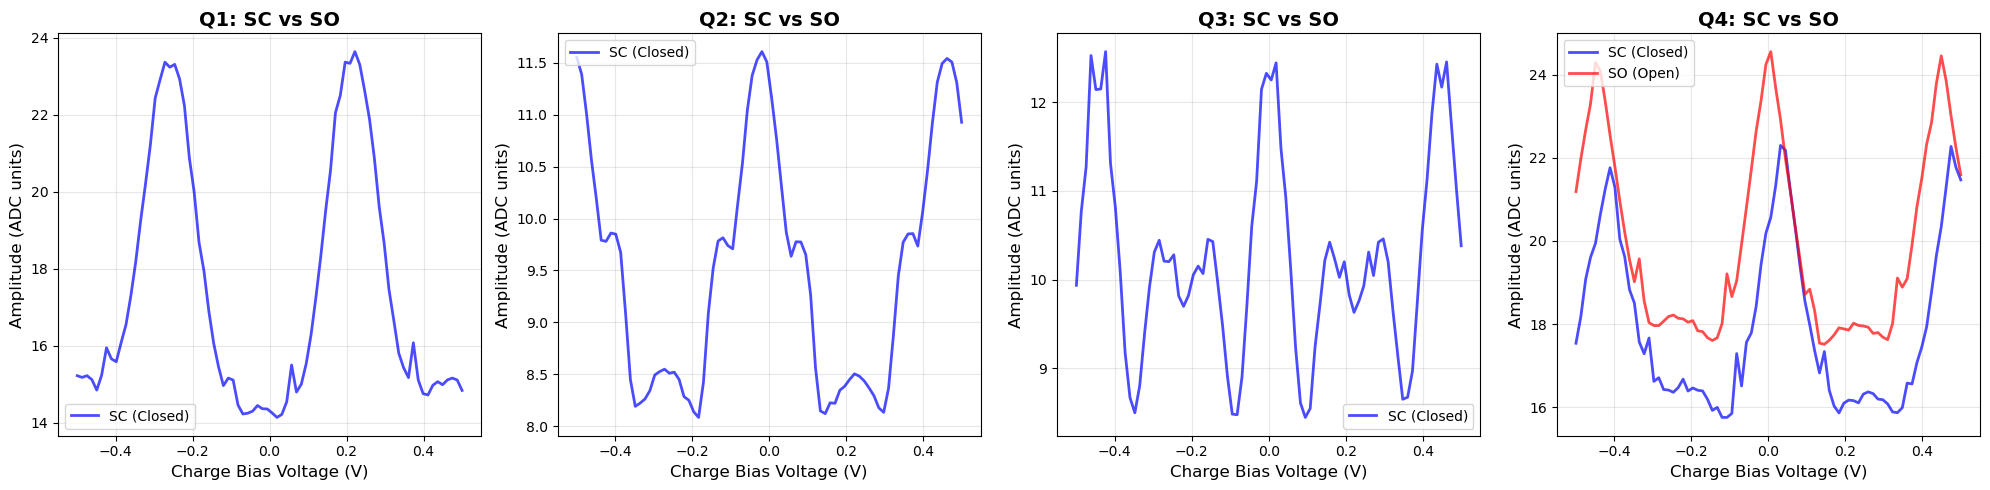

In [ ]:
import glob
import numpy as np
import os
from collections import defaultdict
import matplotlib.pyplot as plt

# Step 1: Load all templates
all_files = sorted(glob.glob(os.path.join(template_datapath, '*templ_full*.npy')))

print(f"Total template files found: {len(all_files)}")
print("="*80)

# Organize templates by qubit and state (SC/SO)
templates = defaultdict(lambda: defaultdict(list))

for file in all_files:
    filename = os.path.basename(file)
    
    # Parse filename: Q1_SC_templ_full.npy
    parts = filename.split('_')
    
    if len(parts) >= 2:
        qubit = parts[0]  # Q1, Q2, Q3, Q4
        state = parts[1]  # SC (closed) or SO (open)
        
        # Load the template
        template = np.load(file, allow_pickle=True)
        
        templates[qubit][state].append({
            'filename': filename,
            'filepath': file,
            'data': template
        })
        
        print(f"Loaded: {filename} -> Qubit: {qubit}, State: {state}, Shape: {template.shape}")

# Step 2: Load vsweep
os.chdir(basedir + 'Data')
vsweep = np.load('vsweep.npy', allow_pickle=True)

# Step 3: Plot everything
qubits = sorted(templates.keys())
states = ['SC', 'SO']  # Closed and Open

# Create subplots - 2 rows (SC/SO) x N columns (qubits)
n_qubits = len(qubits)
fig, axes = plt.subplots(2, n_qubits, figsize=(5*n_qubits, 8))

# Handle case of single qubit
if n_qubits == 1:
    axes = axes.reshape(2, 1)

for col, qubit in enumerate(qubits):
    for row, state in enumerate(states):
        ax = axes[row, col]
        
        if state in templates[qubit] and len(templates[qubit][state]) > 0:
            # Get template data
            template_data = templates[qubit][state][0]['data']
            
            # Plot (use first n_inputs points if template is longer)
            plot_data = template_data[:len(vsweep)] if len(template_data) > len(vsweep) else template_data
            plot_vsweep = vsweep[:len(plot_data)]
            
            ax.plot(plot_vsweep, plot_data, linewidth=2, color='blue' if state == 'SC' else 'red')
            ax.set_title(f'{qubit} {state} ({"Closed" if state == "SC" else "Open"})', fontsize=12, fontweight='bold')
            ax.set_xlabel('Charge Bias Voltage (V)', fontsize=10)
            ax.set_ylabel('Amplitude (ADC units)', fontsize=10)
            ax.grid(True, alpha=0.3)
            
            # Add info text
            info_text = f'Shape: {template_data.shape}\nFile: {templates[qubit][state][0]["filename"]}'
            ax.text(0.02, 0.98, info_text, transform=ax.transAxes, 
                   fontsize=8, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        else:
            ax.text(0.5, 0.5, f'{qubit} {state}\nNot Available', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_xlabel('Charge Bias Voltage (V)', fontsize=10)
            ax.set_ylabel('Amplitude (ADC units)', fontsize=10)

plt.tight_layout()
plt.suptitle('All Qubit Templates: SC (Closed) vs SO (Open)', fontsize=16, fontweight='bold', y=1.00)
plt.subplots_adjust(top=0.96)
plt.show()

# Overlay plots
fig2, axes2 = plt.subplots(1, n_qubits, figsize=(5*n_qubits, 5))

if n_qubits == 1:
    axes2 = [axes2]

for col, qubit in enumerate(qubits):
    ax = axes2[col]
    
    # Plot SC (closed)
    if 'SC' in templates[qubit] and len(templates[qubit]['SC']) > 0:
        template_data = templates[qubit]['SC'][0]['data']
        plot_data = template_data[:len(vsweep)]
        plot_vsweep = vsweep[:len(plot_data)]
        ax.plot(plot_vsweep, plot_data, linewidth=2, color='blue', label='SC (Closed)', alpha=0.7)
    
    # Plot SO (open)
    if 'SO' in templates[qubit] and len(templates[qubit]['SO']) > 0:
        template_data = templates[qubit]['SO'][0]['data']
        plot_data = template_data[:len(vsweep)]
        plot_vsweep = vsweep[:len(plot_data)]
        ax.plot(plot_vsweep, plot_data, linewidth=2, color='red', label='SO (Open)', alpha=0.7)
    
    ax.set_title(f'{qubit}: SC vs SO', fontsize=14, fontweight='bold')
    ax.set_xlabel('Charge Bias Voltage (V)', fontsize=12)
    ax.set_ylabel('Amplitude (ADC units)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#make new template to begin where last iteration end

def new_templ(templ, i_jump, rep, n_inputs):
    
    #make sure new template have the same length
    new_templ = np.empty_like(templ)
    
    #set each point 
    i=0
    while i<n_inputs:
        new_templ[i] = templ[(i+i_jump-rep)%n_inputs]
        i += 1
    
    #return
    return new_templ
    

do_jump: [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
jump indices (vi_list): [ 0  0 77  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 30  0 11
  0  0  0  0  0  0  0  0  0  0  8  0  0  0  0  0  0  0  0  0  0 26  0  0
  0 50  0  0  0  0 19 55  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 31  0  0  0]


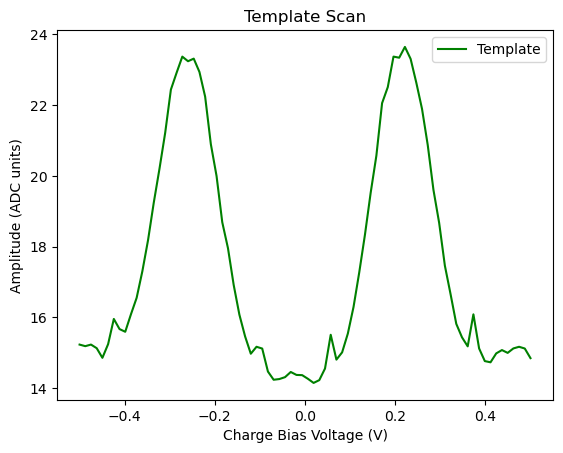

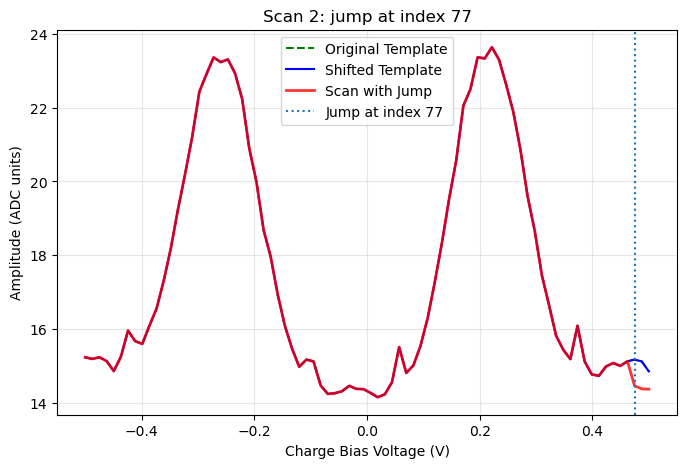

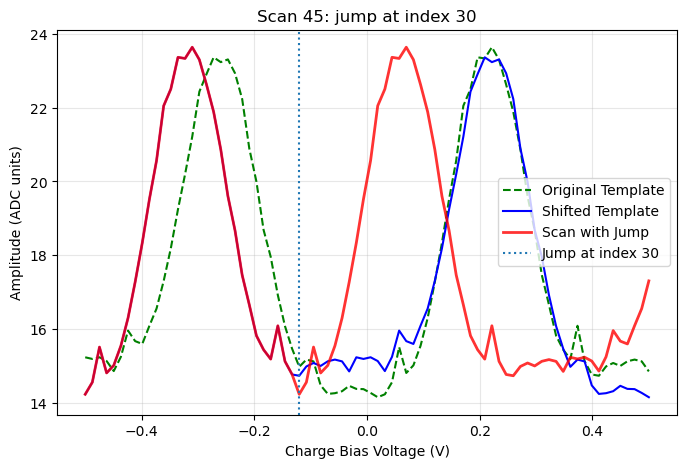

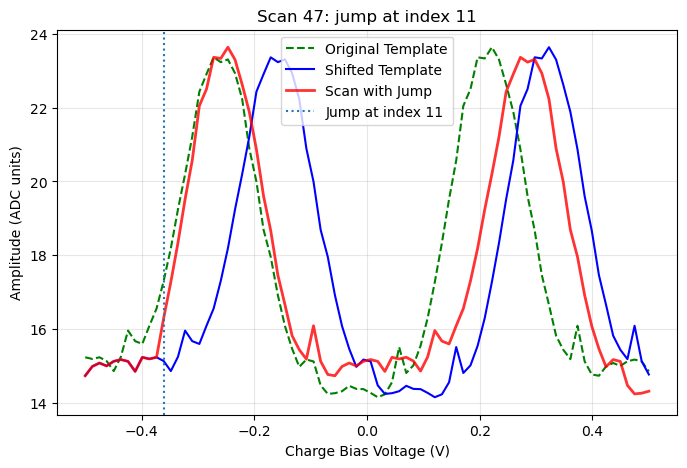

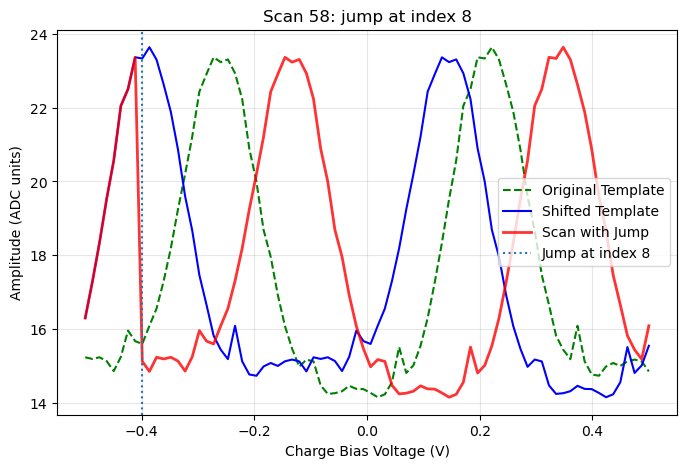

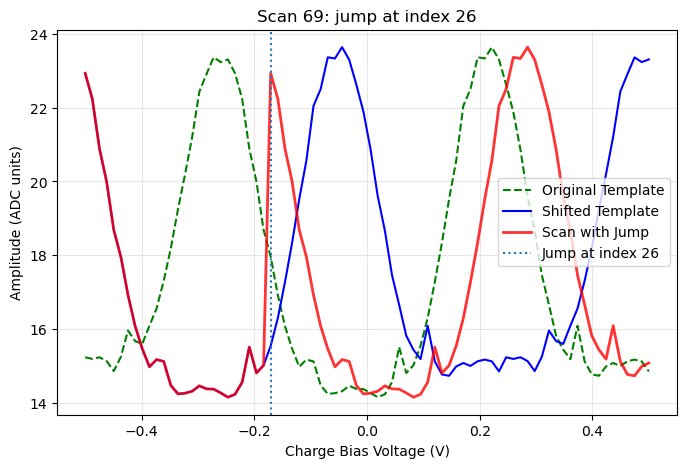

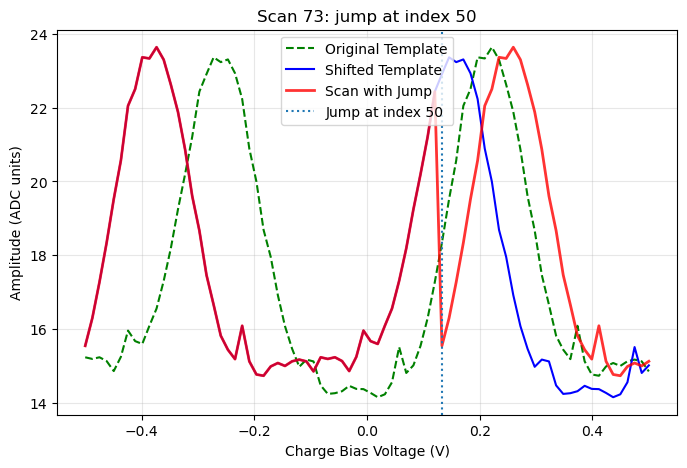

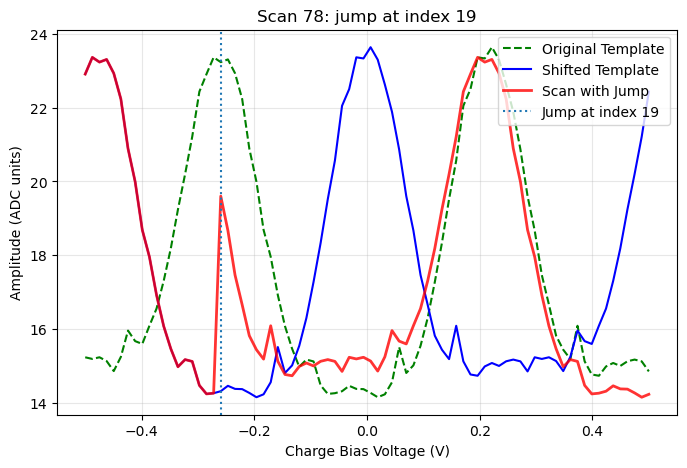

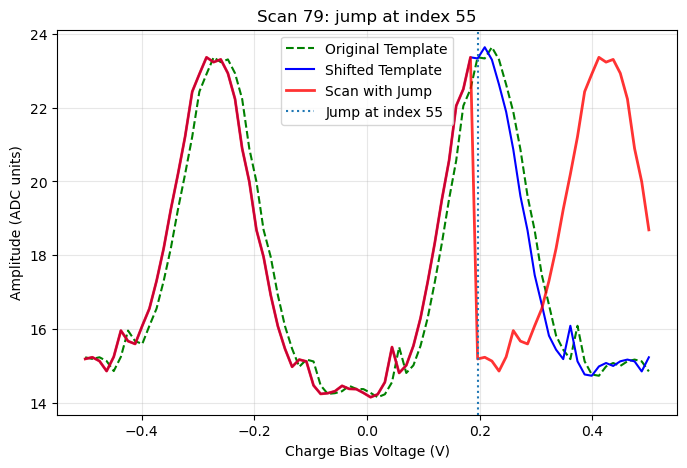

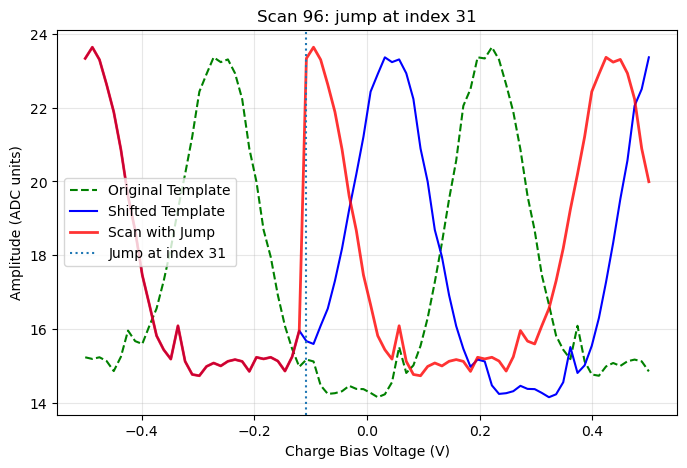

In [ ]:
f = 0.05
n_scans = 100               
n_inputs = len(Q1_templ)    

# Make a temporary template for transform
# Read ONLY templates with 'templ_full' in the filename
all_files = sorted(glob.glob(os.path.join(template_datapath, '*templ_full*.npy')))
all_scans = [np.load(file, allow_pickle=True) for file in all_files]

Q1_current  = all_scans[0]
Q1_jump = all_scans[0]
Q1_templ = all_scans[0]

vsweep_scan = vsweep[:n_inputs]

# Randomly apply jump
do_jump = np.random.choice([0, 1], size=n_scans, p=[1 - f, f])

vi_list = np.zeros(n_scans, dtype=int)
vi_list[do_jump == 1] = np.random.randint(0, n_inputs, size=np.sum(do_jump == 1))

print("do_jump:", do_jump)
print("jump indices (vi_list):", vi_list)

# Print template
# Load vsweep
os.chdir(basedir+'Data')
vsweep = np.load('vsweep.npy', allow_pickle=True)

# Plot without error
plt.title(f"Template Scan")
plt.plot(vsweep, Q1_templ, color='green', label='Template')
plt.xlabel("Charge Bias Voltage (V)")
plt.ylabel("Amplitude (ADC units)")
plt.legend() 
plt.show()

for scan_idx in range(n_scans):

    # No jump: do nothing
    if do_jump[scan_idx] == 0:
        continue

    # Has jump: apply jump
    i_jump = int(vi_list[scan_idx])

    Q1_jump = apply_jump(Q1_current, i_jump)

    if i_jump <= 20 or i_jump >= 70:
        rep = 35
    else:
        rep = 0

    # Plot everything
    plt.figure(figsize=(8, 5))
    plt.plot(vsweep_scan, Q1_templ[:n_inputs], label='Original Template', color='green', linestyle='--')
    plt.plot(vsweep_scan, Q1_current[:n_inputs], label=f'Shifted Template', color='blue')
    plt.plot(vsweep_scan, Q1_jump[:n_inputs], label='Scan with Jump', alpha=0.8, color='red', linewidth=2)
    plt.axvline(vsweep_scan[i_jump],linestyle=':', label=f'Jump at index {i_jump}')

    plt.xlabel("Charge Bias Voltage (V)")
    plt.ylabel("Amplitude (ADC units)")
    plt.title(f"Scan {scan_idx}: jump at index {i_jump}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Update template
    Q1_current = new_templ(Q1_current, i_jump, rep, n_inputs)

Applied phase shift: -5 samples
Applied noise amplitude: 0.2500
Original template std: 3.1532
SNR: 12.61

do_jump: [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
jump indices (vi_list): [ 0  0  0  0  0  0  0  0 54  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0 24  0  0  0  0  0  0  0 69  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  6  0  0]


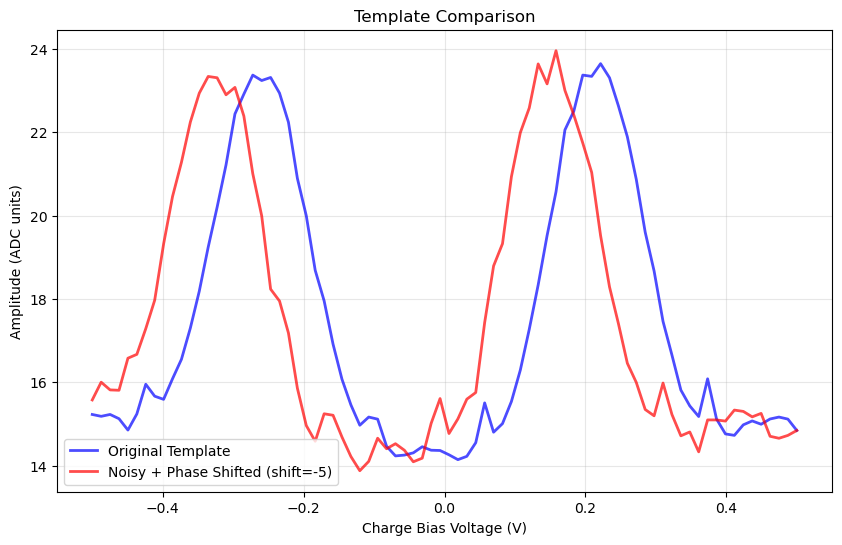

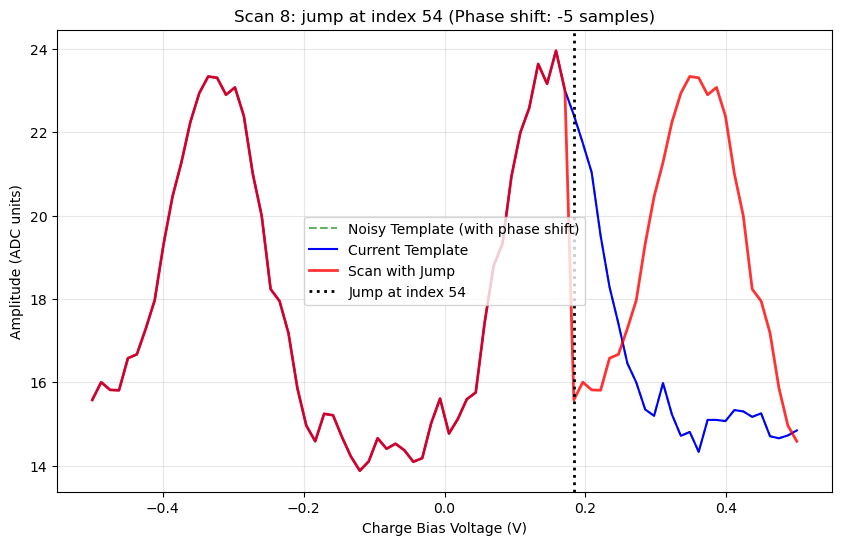

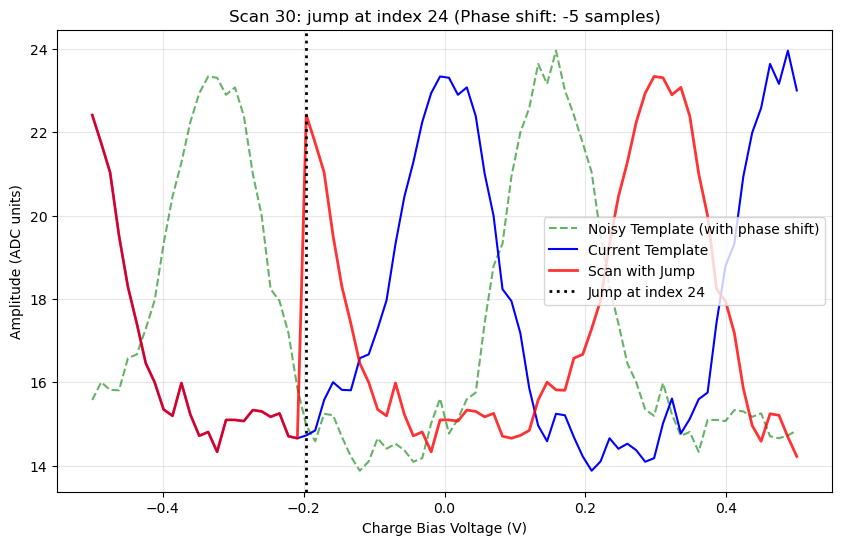

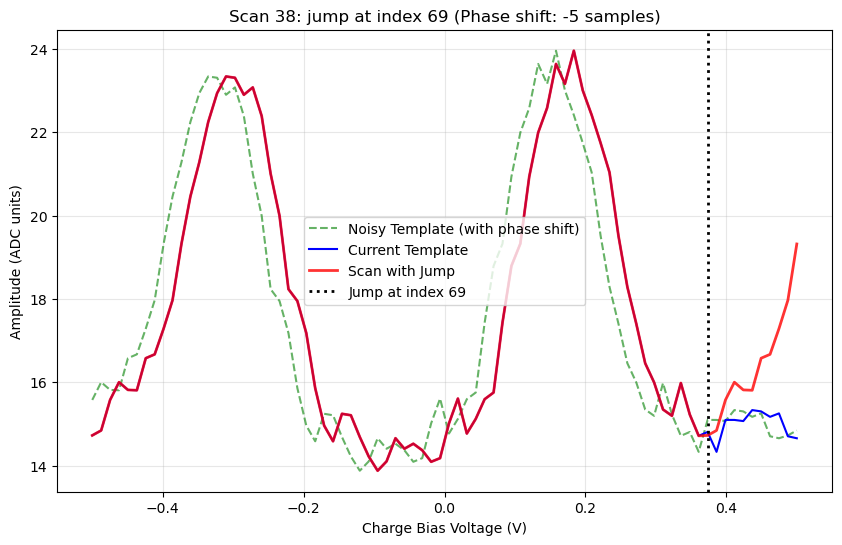

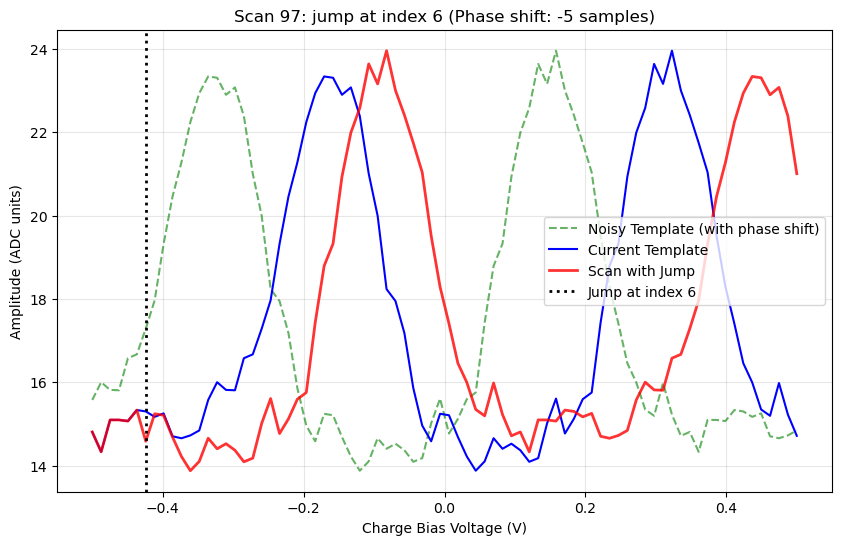

In [ ]:
import glob
import numpy as np
import os
import matplotlib.pyplot as plt

f = 0.05
n_scans = 100               

# Read ONLY templates with 'templ_full' in the filename
all_files = sorted(glob.glob(os.path.join(template_datapath, '*templ_full*.npy')))
all_scans = [np.load(file, allow_pickle=True) for file in all_files]

# Store original clean template
Q1_templ_original = all_scans[0]
n_inputs = len(Q1_templ_original)

# Load vsweep
os.chdir(basedir+'Data')
vsweep = np.load('vsweep.npy', allow_pickle=True)
vsweep_scan = vsweep[:n_inputs]

# ===== APPLY PHASE SHIFT =====
max_shift = len(Q1_templ_original) // 10  # Max shift of 10% of signal length
random_shift = np.random.randint(-max_shift, max_shift)
Q1_templ_shifted = np.roll(Q1_templ_original, random_shift)

# ===== APPLY GAUSSIAN NOISE =====
noise_amplitude = 0.25  # Adjust this value as needed
noise = np.random.normal(0, noise_amplitude, Q1_templ_shifted.shape)
Q1_templ = Q1_templ_shifted + noise

# Initialize with noisy, phase-shifted template
Q1_current = Q1_templ.copy()
Q1_jump = Q1_templ.copy()

print(f"Applied phase shift: {random_shift} samples")
print(f"Applied noise amplitude: {noise_amplitude:.4f}")
print(f"Original template std: {np.std(Q1_templ_original):.4f}")
print(f"SNR: {np.std(Q1_templ_original) / noise_amplitude:.2f}\n")

# Randomly apply jump
do_jump = np.random.choice([0, 1], size=n_scans, p=[1 - f, f])
vi_list = np.zeros(n_scans, dtype=int)
vi_list[do_jump == 1] = np.random.randint(0, n_inputs, size=np.sum(do_jump == 1))

print("do_jump:", do_jump)
print("jump indices (vi_list):", vi_list)

# Plot template comparison
plt.figure(figsize=(10, 6))
plt.plot(vsweep, Q1_templ_original, color='blue', label='Original Template', alpha=0.7, linewidth=2)
plt.plot(vsweep, Q1_templ, color='red', label=f'Noisy + Phase Shifted (shift={random_shift})', alpha=0.7, linewidth=2)
plt.title(f"Template Comparison")
plt.xlabel("Charge Bias Voltage (V)")
plt.ylabel("Amplitude (ADC units)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Process scans with jumps
for scan_idx in range(n_scans):
    # No jump: do nothing
    if do_jump[scan_idx] == 0:
        continue
    
    # Has jump: apply jump
    i_jump = int(vi_list[scan_idx])
    Q1_jump = apply_jump(Q1_current, i_jump)
    
    if i_jump <= 20 or i_jump >= 70:
        rep = 35
    else:
        rep = 0
    
    # Plot everything
    plt.figure(figsize=(10, 6))
    plt.plot(vsweep_scan, Q1_templ[:n_inputs], label='Noisy Template (with phase shift)', color='green', linestyle='--', alpha=0.6)
    plt.plot(vsweep_scan, Q1_current[:n_inputs], label=f'Current Template', color='blue', linewidth=1.5)
    plt.plot(vsweep_scan, Q1_jump[:n_inputs], label='Scan with Jump', alpha=0.8, color='red', linewidth=2)
    plt.axvline(vsweep_scan[i_jump], linestyle=':', color='black', linewidth=2, label=f'Jump at index {i_jump}')
    plt.xlabel("Charge Bias Voltage (V)")
    plt.ylabel("Amplitude (ADC units)")
    plt.title(f"Scan {scan_idx}: jump at index {i_jump} (Phase shift: {random_shift} samples)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Update template
    Q1_current = new_templ(Q1_current, i_jump, rep, n_inputs)

Applied phase shift: -5 samples
Applied noise amplitude: 0.5000
Template std: 3.1532
SNR: 6.31

do_jump: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
jump indices (vi_list): [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 30  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 60  0 55  0  0
  0 34  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0]


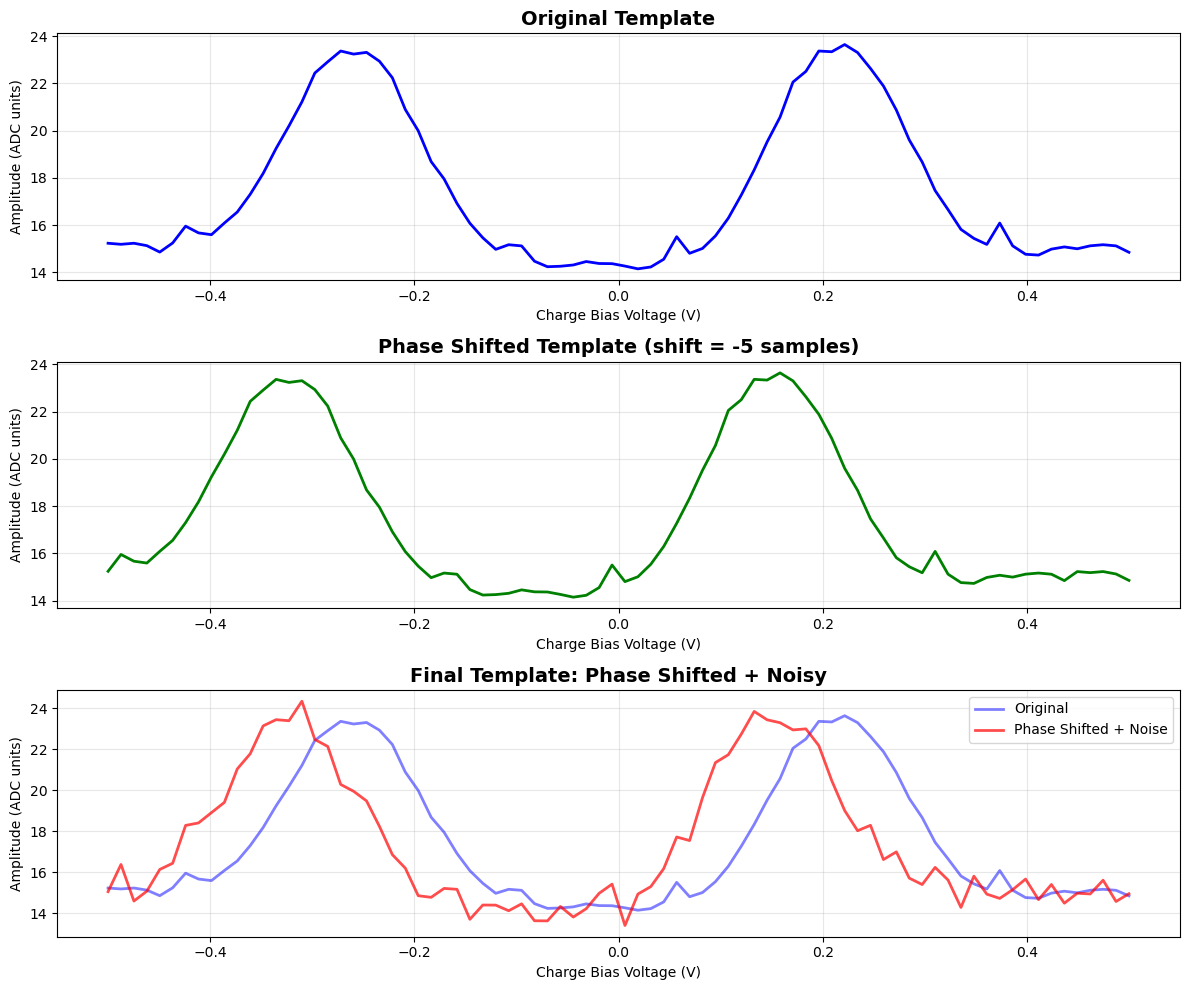

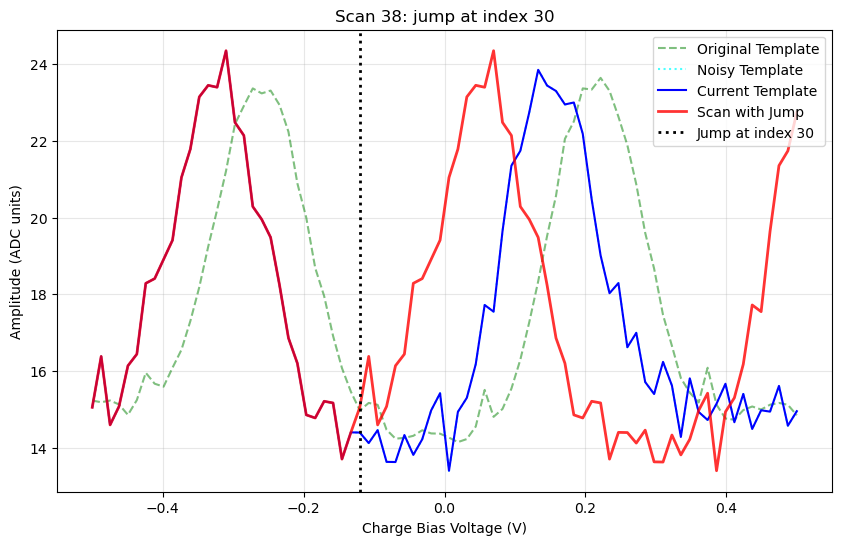

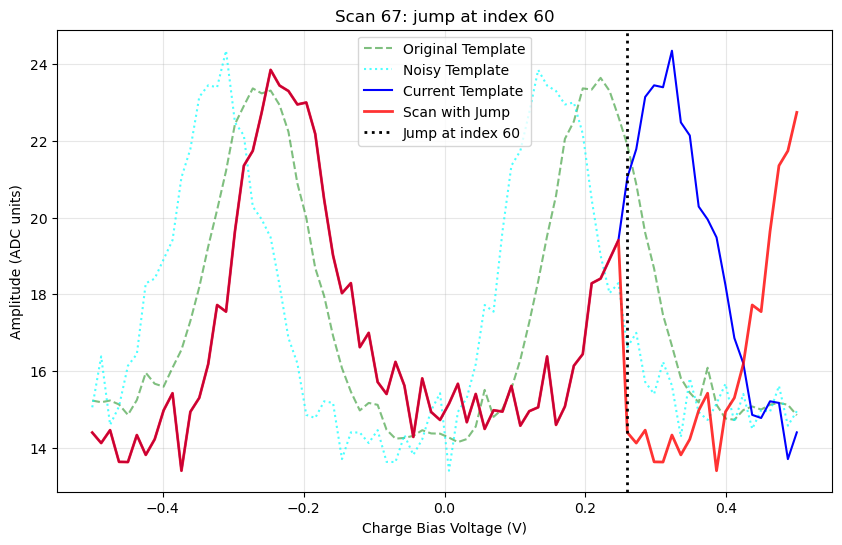

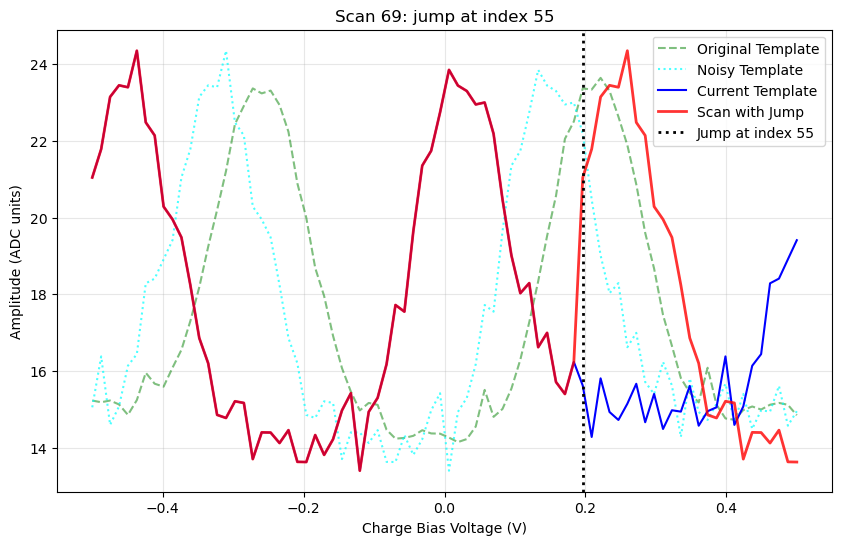

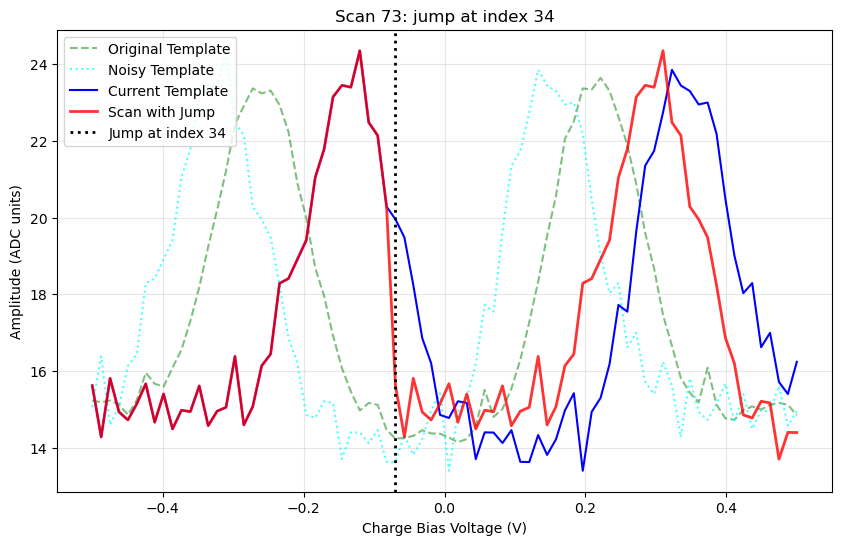

In [ ]:
import glob
import numpy as np
import os
import matplotlib.pyplot as plt

f = 0.05
n_scans = 100               

# Read ONLY templates with 'templ_full' in the filename
all_files = sorted(glob.glob(os.path.join(template_datapath, '*templ_full*.npy')))
all_scans = [np.load(file, allow_pickle=True) for file in all_files]

# Load vsweep
os.chdir(basedir+'Data')
vsweep = np.load('vsweep.npy', allow_pickle=True)

# Get original template
Q1_templ_original = all_scans[0]
n_inputs = len(Q1_templ_original)
vsweep_scan = vsweep[:n_inputs]

# ===== APPLY NOISE AND PHASE SHIFT TO THE TEMPLATE =====
# Add random phase shift (shift the signal in time/voltage space)
max_shift = len(Q1_templ_original) // 10  # Max shift of 10% of signal length
random_shift = np.random.randint(-max_shift, max_shift)
Q1_templ_shifted = np.roll(Q1_templ_original, random_shift)

# Add Gaussian noise
noise_amplitude = 0.5  # Adjust this value as needed
noise = np.random.normal(0, noise_amplitude, Q1_templ_shifted.shape)
Q1_templ = Q1_templ_shifted + noise

print(f"Applied phase shift: {random_shift} samples")
print(f"Applied noise amplitude: {noise_amplitude:.4f}")
print(f"Template std: {np.std(Q1_templ_original):.4f}")
print(f"SNR: {np.std(Q1_templ_original) / noise_amplitude:.2f}")

# Initialize current template with noisy, phase-shifted version
Q1_current = Q1_templ.copy()
Q1_jump = Q1_templ.copy()

# Randomly apply jump
do_jump = np.random.choice([0, 1], size=n_scans, p=[1 - f, f])
vi_list = np.zeros(n_scans, dtype=int)
#vi_list[do_jump == 1] = np.random.randint(0, n_inputs, size=np.sum(do_jump == 1))
# Generate jumps only in the valid range (21 to 69)
n_jumps_needed = np.sum(do_jump == 1)
vi_list[do_jump == 1] = np.random.randint(25, 65, size=n_jumps_needed)

print("\ndo_jump:", do_jump)
print("jump indices (vi_list):", vi_list)

# Plot comparison: Original vs Phase-Shifted vs Noisy
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Original template
axes[0].plot(vsweep_scan, Q1_templ_original[:n_inputs], color='blue', linewidth=2)
axes[0].set_title('Original Template', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Charge Bias Voltage (V)')
axes[0].set_ylabel('Amplitude (ADC units)')
axes[0].grid(True, alpha=0.3)

# Phase shifted template
axes[1].plot(vsweep_scan, Q1_templ_shifted[:n_inputs], color='green', linewidth=2)
axes[1].set_title(f'Phase Shifted Template (shift = {random_shift} samples)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Charge Bias Voltage (V)')
axes[1].set_ylabel('Amplitude (ADC units)')
axes[1].grid(True, alpha=0.3)

# Phase shifted + noisy template
axes[2].plot(vsweep_scan, Q1_templ_original[:n_inputs], color='blue', alpha=0.5, label='Original', linewidth=2)
axes[2].plot(vsweep_scan, Q1_templ[:n_inputs], color='red', alpha=0.7, label='Phase Shifted + Noise', linewidth=2)
axes[2].set_title('Final Template: Phase Shifted + Noisy', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Charge Bias Voltage (V)')
axes[2].set_ylabel('Amplitude (ADC units)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Process scans with jumps
for scan_idx in range(n_scans):
    # No jump: do nothing
    if do_jump[scan_idx] == 0:
        continue
    
    # Has jump: apply jump
    i_jump = int(vi_list[scan_idx])
    Q1_jump = apply_jump(Q1_current, i_jump)
    
    if i_jump <= 20 or i_jump >= 70:
        rep = 35
    else:
        rep = 0
    
    # Plot everything
    plt.figure(figsize=(10, 6))
    plt.plot(vsweep_scan, Q1_templ_original[:n_inputs], label='Original Template', color='green', linestyle='--', alpha=0.5)
    plt.plot(vsweep_scan, Q1_templ[:n_inputs], label='Noisy Template', color='cyan', linestyle=':', alpha=0.7)
    plt.plot(vsweep_scan, Q1_current[:n_inputs], label=f'Current Template', color='blue', linewidth=1.5)
    plt.plot(vsweep_scan, Q1_jump[:n_inputs], label='Scan with Jump', alpha=0.8, color='red', linewidth=2)
    plt.axvline(vsweep_scan[i_jump], linestyle=':', color='black', linewidth=2, label=f'Jump at index {i_jump}')
    plt.xlabel("Charge Bias Voltage (V)")
    plt.ylabel("Amplitude (ADC units)")
    plt.title(f"Scan {scan_idx}: jump at index {i_jump}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Update template
    Q1_current = new_templ(Q1_current, i_jump, rep, n_inputs)

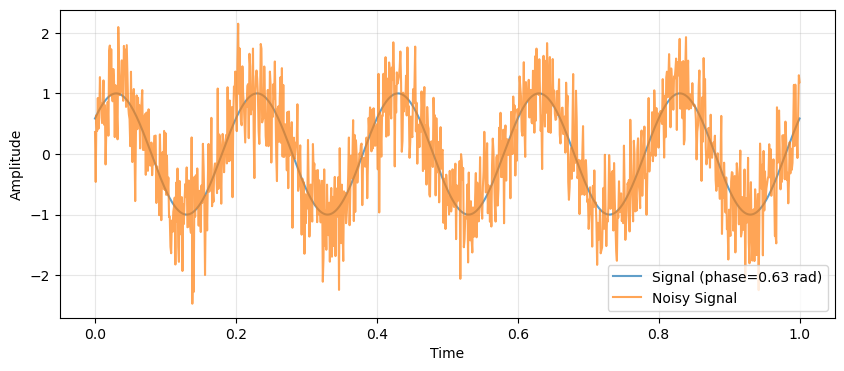

Random phase: 0.626 radians (35.8 degrees)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a sample signal with random phase
t = np.linspace(0, 1, 1000)
random_phase = np.random.uniform(0, 2*np.pi)  # Random phase between 0 and 2π
signal = np.sin(2 * np.pi * 5 * t + random_phase)  # 5 Hz sine wave with random phase

# Add Gaussian noise
noise_amplitude = 0.5
noise = np.random.normal(0, noise_amplitude, signal.shape)
noisy_signal = signal + noise

# Plot
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label=f'Signal (phase={random_phase:.2f} rad)', alpha=0.7)
plt.plot(t, noisy_signal, label='Noisy Signal', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Random phase: {random_phase:.3f} radians ({np.degrees(random_phase):.1f} degrees)")

Looking in: /home/export/jgaytanv/quantum/NEXUS_Qubits/SimulatedData_Gen/Templates/
Total template files found: 5
Loaded: Q1_SC_templ_full.npy -> Qubit: Q1, State: SC, Shape: (80,)
Loaded: Q2_SC_templ_full.npy -> Qubit: Q2, State: SC, Shape: (80,)
Loaded: Q3_SC_templ_full.npy -> Qubit: Q3, State: SC, Shape: (80,)
Loaded: Q4_SC_templ_full.npy -> Qubit: Q4, State: SC, Shape: (80,)
Loaded: Q4_SO_templ_full.npy -> Qubit: Q4, State: SO, Shape: (80,)

Loaded vsweep shape: (80,)

Using template: Q1_SC_templ_full.npy


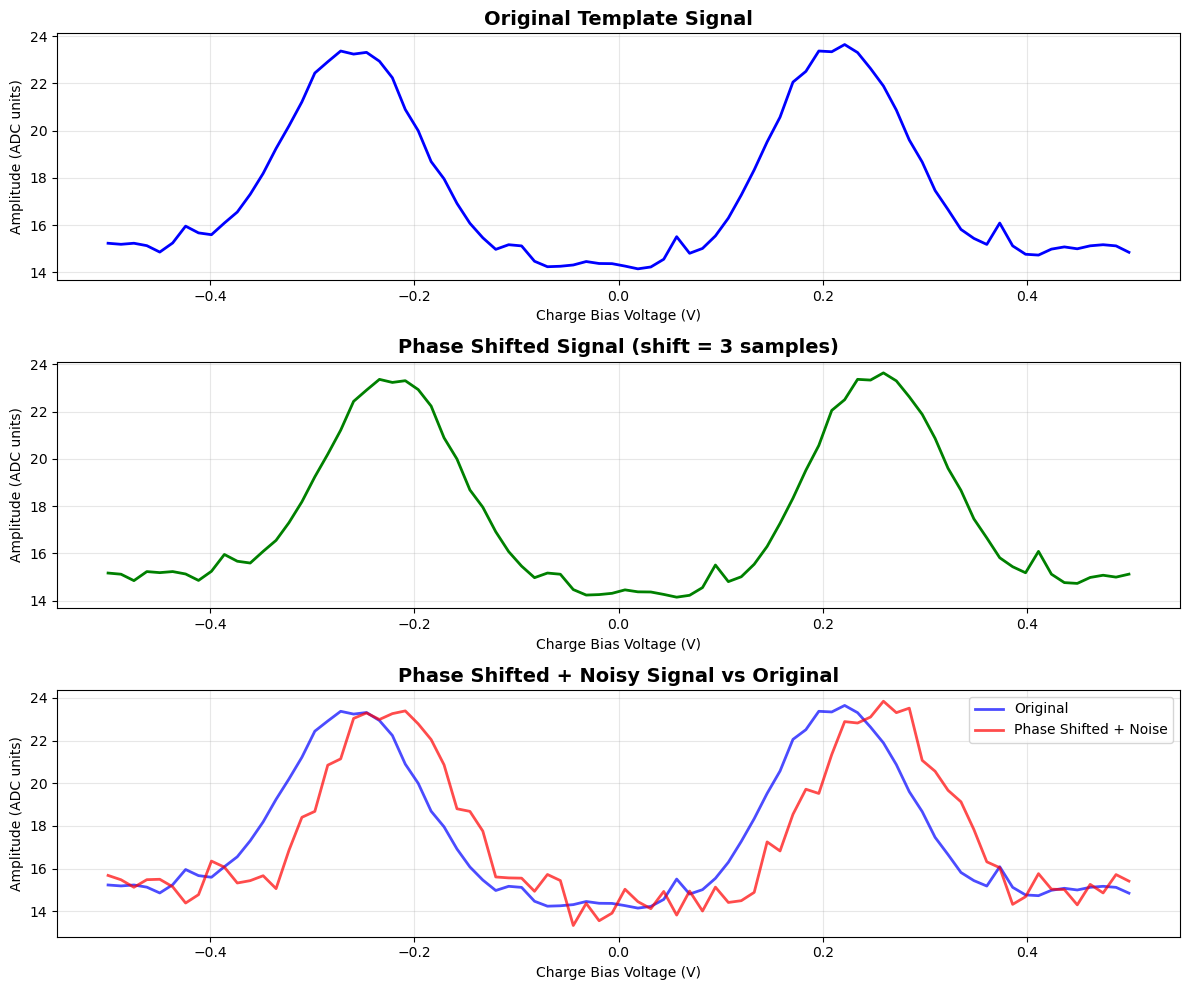


Random phase shift: 3 samples
Noise amplitude (std): 0.5000
Signal std: 3.1532
SNR: 6.31


In [ ]:
import glob
import numpy as np
import os
import matplotlib.pyplot as plt
from collections import defaultdict

# Step 1: Load all templates from the correct directory
template_datapath = basedir + 'SimulatedData_Gen/Templates/'
all_files = sorted(glob.glob(os.path.join(template_datapath, '*templ_full*.npy')))

print(f"Looking in: {template_datapath}")
print(f"Total template files found: {len(all_files)}")

# Organize templates by qubit and state (SC/SO)
templates = defaultdict(lambda: defaultdict(list))

for file in all_files:
    filename = os.path.basename(file)
    
    # Parse filename: Q1_SC_templ_full.npy
    parts = filename.split('_')
    
    if len(parts) >= 2:
        qubit = parts[0]  # Q1, Q2, Q3, Q4
        state = parts[1]  # SC (closed) or SO (open)
        
        # Load the template
        template = np.load(file, allow_pickle=True)
        
        templates[qubit][state].append({
            'filename': filename,
            'filepath': file,
            'data': template
        })
        
        print(f"Loaded: {filename} -> Qubit: {qubit}, State: {state}, Shape: {template.shape}")

# Step 2: Load vsweep from the Data directory
data_path = basedir + 'Data/'
vsweep = np.load(os.path.join(data_path, 'vsweep.npy'), allow_pickle=True)
print(f"\nLoaded vsweep shape: {vsweep.shape}")

# Step 3: Select one template for noise demonstration
qubits = sorted(templates.keys())
if len(qubits) > 0:
    qubit = qubits[0]  # First qubit
    state = 'SC' if 'SC' in templates[qubit] else list(templates[qubit].keys())[0]
    
    # Get the template
    template = templates[qubit][state][0]['data']
    print(f"\nUsing template: {templates[qubit][state][0]['filename']}")
else:
    raise ValueError("No templates found!")

# Ensure they have compatible lengths
signal = template[:len(vsweep)]
x_axis = vsweep[:len(signal)]

# Add random phase shift (shift the signal in time/voltage space)
max_shift = len(signal) // 10  # Max shift of 10% of signal length
random_shift = np.random.randint(-max_shift, max_shift)
phase_shifted_signal = np.roll(signal, random_shift)

# Add Gaussian noise (using the same method as the snippet)
noise_amplitude = 0.5  # You can adjust this value
noise = np.random.normal(0, noise_amplitude, signal.shape)
noisy_signal = phase_shifted_signal + noise

# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Original signal
axes[0].plot(x_axis, signal, linewidth=2, color='blue')
axes[0].set_title('Original Template Signal', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Charge Bias Voltage (V)')
axes[0].set_ylabel('Amplitude (ADC units)')
axes[0].grid(True, alpha=0.3)

# Phase shifted signal
axes[1].plot(x_axis, phase_shifted_signal, linewidth=2, color='green')
axes[1].set_title(f'Phase Shifted Signal (shift = {random_shift} samples)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Charge Bias Voltage (V)')
axes[1].set_ylabel('Amplitude (ADC units)')
axes[1].grid(True, alpha=0.3)

# Phase shifted + noisy signal
axes[2].plot(x_axis, signal, linewidth=2, color='blue', alpha=0.7, label='Original')
axes[2].plot(x_axis, noisy_signal, linewidth=2, color='red', alpha=0.7, label='Phase Shifted + Noise')
axes[2].set_title('Phase Shifted + Noisy Signal vs Original', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Charge Bias Voltage (V)')
axes[2].set_ylabel('Amplitude (ADC units)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRandom phase shift: {random_shift} samples")
print(f"Noise amplitude (std): {noise_amplitude:.4f}")
print(f"Signal std: {np.std(signal):.4f}")
print(f"SNR: {np.std(signal) / noise_amplitude:.2f}")

In [ ]:
def apply_jump(scan, i_jump, jump="large", edgeOverride=True):
    Q1_longtempl = np.tile(scan, 2)

    max_rep =  len(scan) + i_jump
    candidates = np.random.randint(0, max_rep, size=n_candidates)

    value_before=Q1_longtempl[i_jump - 1] if i_jump>0 else Q1_longtempl[0]

    best_rep=None
    best_score=None

    for rep in candidates:
        
        if rep + (len(scan) - i_jump) > len(Q1_longtempl):
            continue

        value_after=Q1_longtempl[rep]
        jump_size=abs(value_after-value_before)

        if jump=="large":
            if best_score==None or jump_size>best_score:
                best_score=jump_size
                best_rep=rep
        elif jump=="small":
            if best_score==0:
                continue
            if best_score==None or jump_size<best_score:
                best_score=jump_size
                best_rep=rep
        else:
            raise ValueError("must be large or small")
        
    if best_rep==None:
        best_rep=candidates[0]
        best_score=abs(Q1_longtempsl[rep]- value_before)

    rep=best_rep
    chosen_jump_size=best_score

    if edgeOverride and (i_jump<20 or i_jump>70):
        rep=int(np.random.uniform(25,65))
        chosen_jump_size=abs(Q1_longtempl[rep]-value_before)

    part1 = Q1_longtempl[:i_jump]
    part2 = Q1_longtempl[rep : rep + len(scan) - i_jump]
    scan_out = np.concatenate([part1, part2])

    return scan_out, float(chosen_jump_size)

In [ ]:
def apply_jump(scan, i_jump, n_candidates=20):
    """
    Try multiple rep values and pick the one with largest discontinuity
    """
    Q1_longtempl = np.tile(scan, 2)
    
    # Generate candidate rep values
    max_rep =  len(scan) + i_jump
    candidates = np.random.randint(0, max_rep, size=n_candidates)
    
    best_rep = 0
    max_jump_size = 0
    
    for rep in candidates:
        # Check if this rep creates valid indices
        if rep + (len(scan) - i_jump) > len(Q1_longtempl):
            continue
            
        # Calculate jump magnitude at the discontinuity
        value_before = Q1_longtempl[i_jump - 1] if i_jump > 0 else Q1_longtempl[0]
        value_after = Q1_longtempl[rep]
        jump_size = abs(value_after - value_before)
        
        if jump_size > max_jump_size:
            max_jump_size = jump_size
            best_rep = rep
    
    # Use edge case logic if needed
    if i_jump <= 20 or i_jump >= 70:
        rep = int(np.random.uniform(25, 65))
    else:
        rep = best_rep
    
    part1 = Q1_longtempl[:i_jump]
    part2 = Q1_longtempl[rep:rep+len(scan)-i_jump]
    scan = np.concatenate([part1, part2])
    
    return scan, max_jump_size  # Return jump size for diagnostics

Applied phase shift: -2 samples
Applied noise amplitude: 0.1500
Original template std: 3.1532
SNR: 21.02

do_jump: [1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
jump indices (vi_list): [16  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0 31  0  0  0 20  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 27  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 70  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0]


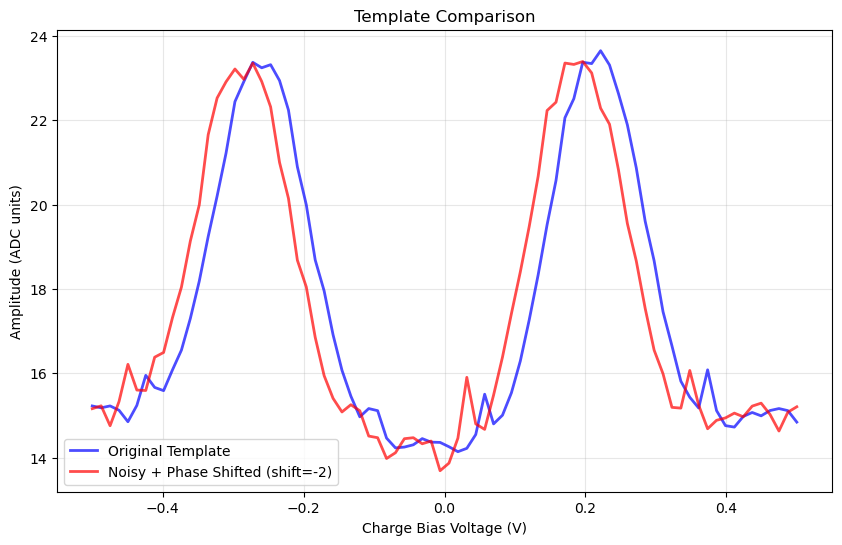

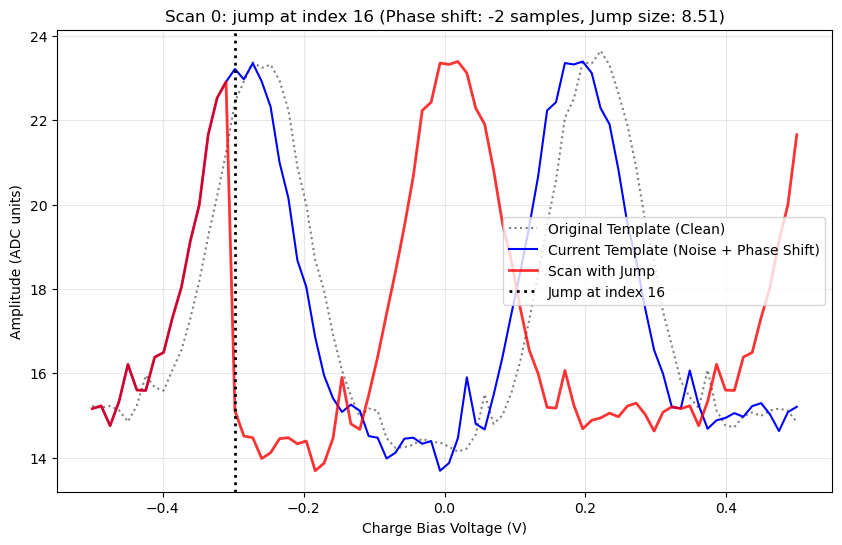

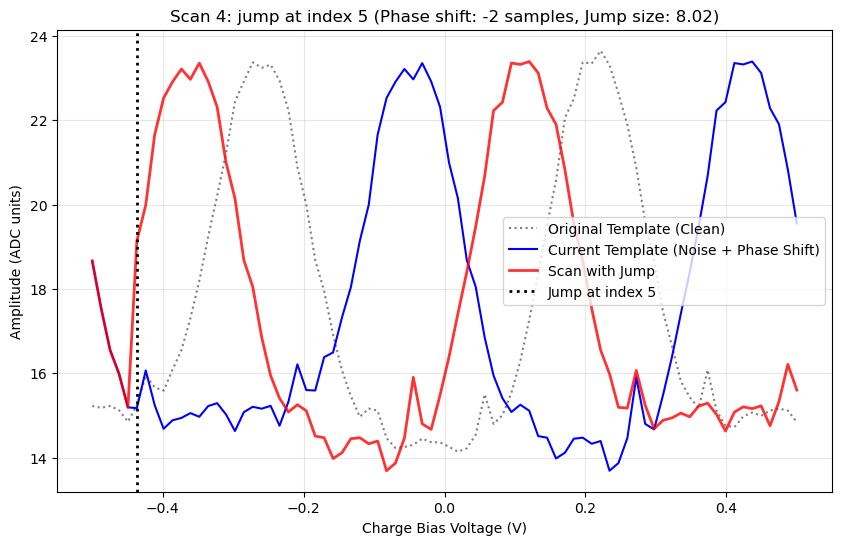

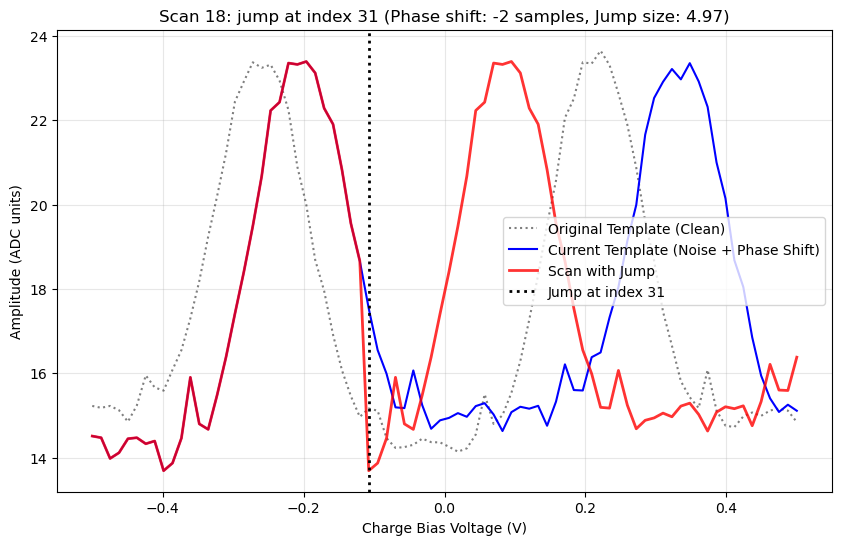

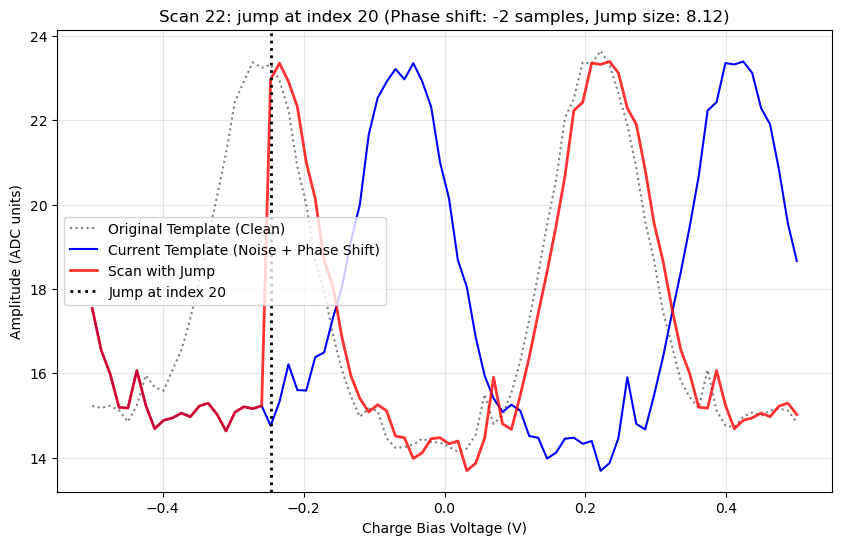

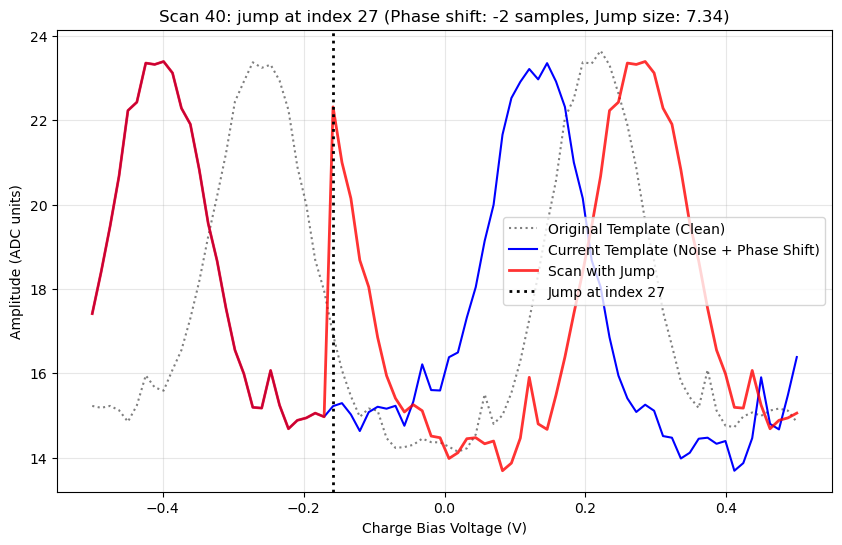

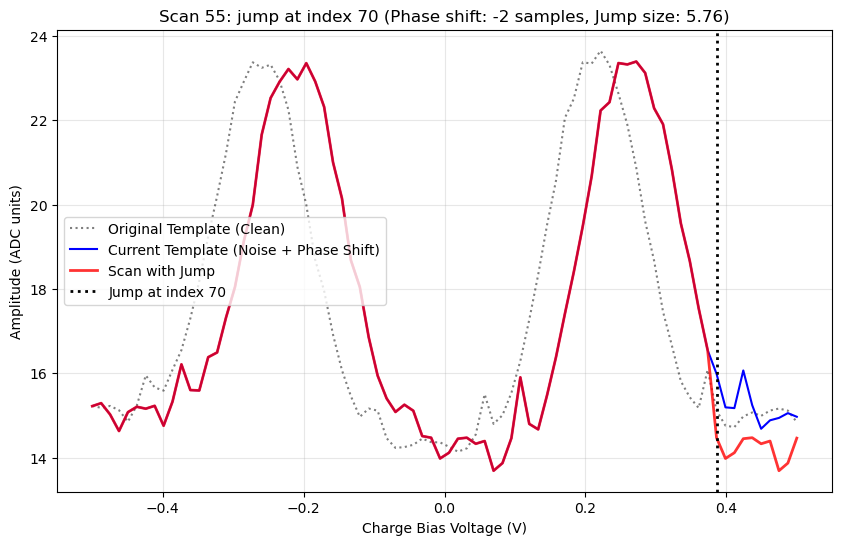

In [ ]:
import glob
import numpy as np
import os
import matplotlib.pyplot as plt

f = 0.05
n_scans = 100               

# Read ONLY templates with 'templ_full' in the filename
all_files = sorted(glob.glob(os.path.join(template_datapath, '*templ_full*.npy')))
all_scans = [np.load(file, allow_pickle=True) for file in all_files]

# Store original clean template
Q1_templ_original = all_scans[0]
n_inputs = len(Q1_templ_original)

# Load vsweep
os.chdir(basedir+'Data')
vsweep = np.load('vsweep.npy', allow_pickle=True)
vsweep_scan = vsweep[:n_inputs]

# ===== APPLY PHASE SHIFT =====
max_shift = len(Q1_templ_original) // 10 # Max shift of 10% of signal length
random_shift = np.random.randint(-max_shift, max_shift)
Q1_templ_shifted = np.roll(Q1_templ_original, random_shift)

# ===== APPLY GAUSSIAN NOISE =====
noise_amplitude = 0.15  # Adjust this value as needed
noise = np.random.normal(0, noise_amplitude, Q1_templ_shifted.shape)
Q1_templ = Q1_templ_shifted + noise

# Initialize with noisy, phase-shifted template
Q1_current = Q1_templ.copy()
Q1_jump = Q1_templ.copy()

print(f"Applied phase shift: {random_shift} samples")
print(f"Applied noise amplitude: {noise_amplitude:.4f}")
print(f"Original template std: {np.std(Q1_templ_original):.4f}")
print(f"SNR: {np.std(Q1_templ_original) / noise_amplitude:.2f}\n")

# Randomly apply jump
do_jump = np.random.choice([0, 1], size=n_scans, p=[1 - f, f])
vi_list = np.zeros(n_scans, dtype=int)
vi_list[do_jump == 1] = np.random.randint(0, n_inputs, size=np.sum(do_jump == 1))

print("do_jump:", do_jump)
print("jump indices (vi_list):", vi_list)

# Plot template comparison
plt.figure(figsize=(10, 6))
plt.plot(vsweep, Q1_templ_original, color='blue', label='Original Template', alpha=0.7, linewidth=2)
plt.plot(vsweep, Q1_templ, color='red', label=f'Noisy + Phase Shifted (shift={random_shift})', alpha=0.7, linewidth=2)
plt.title(f"Template Comparison")
plt.xlabel("Charge Bias Voltage (V)")
plt.ylabel("Amplitude (ADC units)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Process scans with jumps
# Process scans with jumps
for scan_idx in range(n_scans):
    # No jump: do nothing
    if do_jump[scan_idx] == 0:
        continue
    
    # Has jump: apply jump
    i_jump = int(vi_list[scan_idx])
    Q1_jump, jump_magnitude = apply_jump(Q1_current, i_jump)
    
    if i_jump <= 20 or i_jump >= 70:
        rep = 35
    else:
        rep = 0
    
    # Plot everything
    plt.figure(figsize=(10, 6))
    plt.plot(vsweep_scan, Q1_templ_original[:n_inputs], label='Original Template (Clean)', 
             color='black', linestyle=':', alpha=0.5, linewidth=1.5)
    #plt.plot(vsweep_scan, Q1_templ[:n_inputs], label='Noisy Template (with phase shift)', 
    #         color='green', linestyle='--', alpha=0.6, linewidth=1.5)
    plt.plot(vsweep_scan, Q1_current[:n_inputs], label=f'Current Template (Noise + Phase Shift)', 
             color='blue', linewidth=1.5)
    plt.plot(vsweep_scan, Q1_jump[:n_inputs], label='Scan with Jump', 
             alpha=0.8, color='red', linewidth=2)
    plt.axvline(vsweep_scan[i_jump], linestyle=':', color='black', linewidth=2, 
                label=f'Jump at index {i_jump}')
    plt.xlabel("Charge Bias Voltage (V)")
    plt.ylabel("Amplitude (ADC units)")
    plt.title(f"Scan {scan_idx}: jump at index {i_jump} (Phase shift: {random_shift} samples, Jump size: {jump_magnitude:.2f})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Update template
    Q1_current = new_templ(Q1_current, i_jump, rep, n_inputs)